<a href="https://colab.research.google.com/github/Tomas-Turner/Unit1_TheLook_Team10/blob/individual/Unit1_Jack_Strabala_Dive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 1 — AI‑Assisted Exploratory Data Analysis & BI Dashboard**
MGMT 467 · Fall 2025  

**Team Name:** Team 10  
**Members (GitHub handles):** ☐ ☐ ☐ ☐  
**GitHub Repo URL:** ☐  
**Looker Studio Dashboard (public link):** ☐

> **Scenario:** NYC DOT has asked your team to analyze the public Citi Bike program and recommend strategies to improve bike availability and engagement. You will use BigQuery + Gemini to conduct AI‑assisted EDA and publish an executive dashboard.

## ✅ Submission Checklist (Team → Brightspace)
- [ ] GitHub repository link (source of record)
- [ ] Looker Studio dashboard link
- [ ] This notebook committed to GitHub with prompts and results

### ✅ Submission Checklist (Individual → Brightspace)
- [ ] `Contribution_Reflection.pdf` (with commit/PR evidence + peer eval)

## 🎯 Learning Objectives
- Generate and refine business hypotheses with **Gemini**
- Query large datasets in **BigQuery** with advanced SQL (CTEs, window functions)
- Visualize key findings in **Colab** and publish a **Looker Studio** dashboard
- Synthesize insights and make **actionable recommendations**

## 🧰 Setup
> Run the cells below to connect Colab to Google Cloud & BigQuery.

In [ ]:
# Install and import basics (Colab usually has these preinstalled)
# !pip install --quiet google-cloud-bigquery pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt

# Authenticate to Google from Colab
from google.colab import auth  # type: ignore
auth.authenticate_user()

# Set your GCP project ID
PROJECT_ID = "mgmt-467-94721"  # <-- edit this
print("Using project:", PROJECT_ID)

Using project: mgmt-467-94721


In [ ]:
# BigQuery magics (%%bigquery) and client
from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

# Optional: list datasets to verify access
list(client.list_datasets())

## 🧪 Dataset
We will use **Citi Bike Trips**: `bigquery-public-data.new_york_citibike.citibike_trips`  
Feel free to explore additional public datasets if needed.

## 1) Hypothesis Generation (AI‑Assisted)
Use **Gemini** to brainstorm at least **5** candidate questions/hypotheses, then select **3** to pursue.

> **Prompt:**  
> *"You are an analytics co‑pilot. Propose 5 high‑value, testable business questions about the Citi Bike dataset (tripduration, stations, user types, time-of-day/week). Return as bullets with suggested SQL hints."*

**Selected Hypotheses**
1. ☐ What are the busiest start stations in terms of the number of trips?
SQL Hint: Use COUNT(*) and GROUP BY start_station_name on the citibike_trips table.
2. ☐ How does the average trip duration vary between different user types (subscribers vs. customers)?
SQL Hint: Calculate the average of tripduration and GROUP BY usertype on the citibike_trips table.
3. ☐ What are the peak hours and days of the week for Citi Bike usage?
SQL Hint: Extract the hour of the day and day of the week from the starttime column and use COUNT(*) with GROUP BY the extracted time components.



## 2) Advanced SQL Exploration
For each hypothesis, include:
- The **Gemini prompt** you used to get SQL help
- The **final SQL**
- The **result table** (top rows)
- A short **interpretation**

> Tip: Use **CTEs** and at least **one window function** across your work.

### Hypothesis A — Prompt Log

> You are a data analyst for the city of New York. Build an SQL query to help answer this business question: What are the busiest start stations in terms of the number of trips? SQL Hint: Use COUNT(*) and GROUP BY start_station_name on the citibike_trips table. Store results in a pandas data frame. Do not include null values.

In [ ]:
# Hypothesis A — SQL (store results in a Pandas DataFrame)
query_hyp_a = r"""
SELECT
    start_station_name,
    COUNT(*) AS num_trips
FROM
    `bigquery-public-data.new_york_citibike.citibike_trips`
WHERE
    start_station_name IS NOT NULL AND start_station_name != ''
GROUP BY
    start_station_name
ORDER BY
    num_trips DESC
LIMIT 10
"""

df_hyp_a = client.query(query_hyp_a).to_dataframe()
df_hyp_a.head()

,start_station_name,num_trips
0,Pershing Square North,438077
1,E 17 St & Broadway,423334
2,W 21 St & 6 Ave,403795
3,8 Ave & W 31 St,401554
4,West St & Chambers St,384116


SELECT
    start_station_name,
    COUNT(*) AS num_trips
FROM
    `bigquery-public-data.new_york_citibike.citibike_trips`
GROUP BY
    start_station_name
ORDER BY
    num_trips DESC
LIMIT 10;

**Interpretation (2–4 sentences):** ☐ Perishing Square North is the busiest station with the most trips starting from that location, followed by E 17 St & Broadway and W 21 St & 6 Ave. These stations are key locations for Citi Bike usage showing high demand in those areas.

---

### Hypothesis B — Prompt Log

> Paste Gemini prompt(s) and key suggestion(s) here.

**Prompt:**
> You are a data analyst for the city of New York. Build an SQL query to help answer this business question: How does the average trip duration vary between different user types (subscribers vs. customers)? SQL Hint: Calculate the average of tripduration and GROUP BY usertype on the citibike_trips table. Store results in a pandas data frame. Format similarly to the last one.

In [ ]:
# Hypothesis B — SQL
query_hyp_b = r"""
SELECT
    usertype,
    AVG(tripduration) AS average_trip_duration
FROM
    `bigquery-public-data.new_york_citibike.citibike_trips`
WHERE
    usertype IS NOT NULL AND usertype != ''
GROUP BY
    usertype
"""
df_hyp_b = client.query(query_hyp_b).to_dataframe()
df_hyp_b.head()

,usertype,average_trip_duration
0,Customer,2145.512075
1,Subscriber,806.381888


**Interpretation (2–4 sentences):** ☐ The average trip duration is in seconds and the average trip duration is nearly 3 times longer for customers compared to subscribers. This suggests that customers who likely use Citi Bike less frequently, take longer trips compared to subscribers, who might use Citi Bike for comutes or more regular travel.

---

### Hypothesis C — Prompt Log

> Paste Gemini prompt(s) and key suggestion(s) here.

**Prompt:**
> You are a data analyst for the city of New York. Build an SQL query to help answer this business question: What are the peak hours and days of the week for Citi Bike usage? SQL Hint: Extract the hour of the day and day of the week from the starttime column and use COUNT(*) with GROUP BY the extracted time components. Store results in a pandas data frame. Format similarly to the last one.

In [ ]:
# Hypothesis C — SQL
query_hyp_c = r"""
SELECT
    EXTRACT(HOUR FROM starttime) AS peak_hour,
    EXTRACT(DAYOFWEEK FROM starttime) AS peak_day_of_week,
    COUNT(*) AS num_trips
FROM
    `bigquery-public-data.new_york_citibike.citibike_trips`
WHERE
    EXTRACT(HOUR FROM starttime) IS NOT NULL AND EXTRACT(DAYOFWEEK FROM starttime) IS NOT NULL
GROUP BY
    peak_hour,
    peak_day_of_week
ORDER BY
    num_trips DESC
LIMIT 100 # Limiting to a reasonable number for analysis
"""
df_hyp_c = client.query(query_hyp_c).to_dataframe()
display(df_hyp_c.head())

,peak_hour,peak_day_of_week,num_trips
0,18,4,877895
1,18,3,871101
2,17,4,866516
3,17,3,861595
4,17,5,856378


**Interpretation (2–4 sentences):** ☐ The peak hours of Citi Bike usage appear to be in the early evening around hour 17 (5 PM) and hour 18 (6 PM). The busiest days of the week all seem to be weekdays. These patterns reflect typical commuting hours after work during the week.

## 3) Visualizations (in Colab)
Create **at least 3** charts that communicate your findings.  
> Keep charts readable and labeled. Use `matplotlib` (no specific styles required).

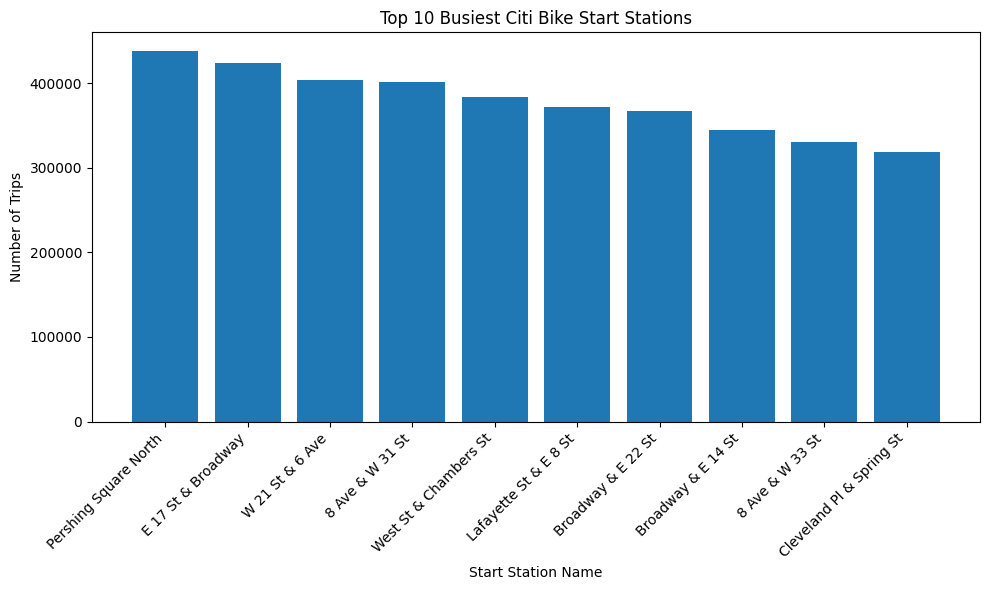

In [ ]:
# Chart for Hypothesis A: Busiest Start Stations
plt.figure(figsize=(10, 6))
plt.bar(df_hyp_a['start_station_name'], df_hyp_a['num_trips'])
plt.xlabel('Start Station Name')
plt.ylabel('Number of Trips')
plt.title('Top 10 Busiest Citi Bike Start Stations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

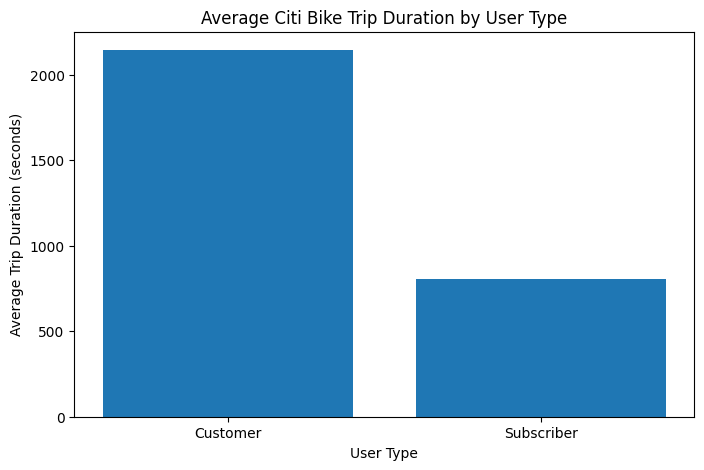

In [ ]:
# Chart for Hypothesis B: Average Trip Duration by User Type
plt.figure(figsize=(8, 5))
plt.bar(df_hyp_b['usertype'], df_hyp_b['average_trip_duration'])
plt.xlabel('User Type')
plt.ylabel('Average Trip Duration (seconds)')
plt.title('Average Citi Bike Trip Duration by User Type')
plt.show()

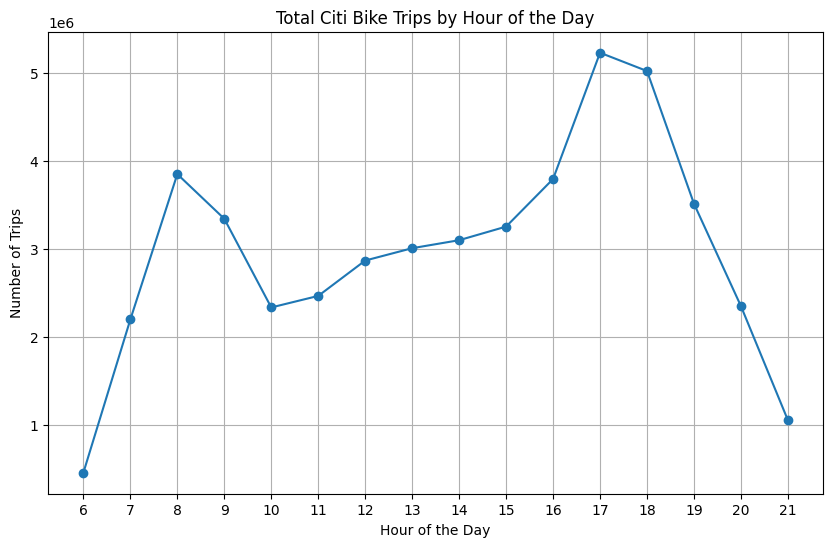

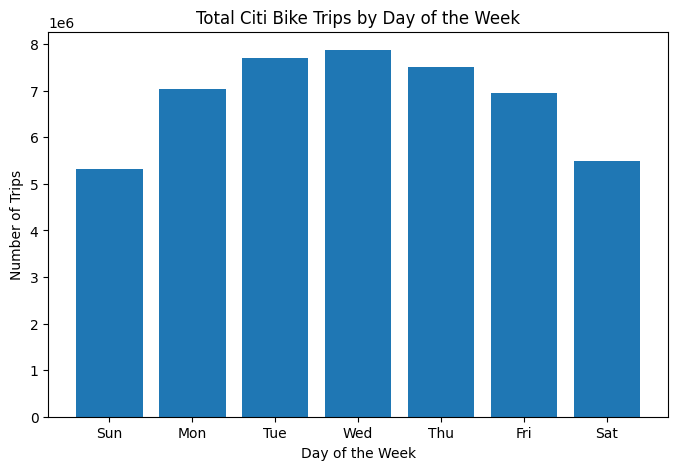

In [ ]:
# Chart for Hypothesis C: Peak Hours and Days of the Week


# Visualize the top hours across all days first
df_peak_hours = df_hyp_c.groupby('peak_hour')['num_trips'].sum().reset_index()
df_peak_hours = df_peak_hours.sort_values(by='peak_hour')

plt.figure(figsize=(10, 6))
plt.plot(df_peak_hours['peak_hour'], df_peak_hours['num_trips'], marker='o')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.title('Total Citi Bike Trips by Hour of the Day')
plt.xticks(df_peak_hours['peak_hour'])
plt.grid(True)
plt.show()

# Visualize trips by day of the week
df_peak_days = df_hyp_c.groupby('peak_day_of_week')['num_trips'].sum().reset_index()
df_peak_days = df_peak_days.sort_values(by='peak_day_of_week')

plt.figure(figsize=(8, 5))
# Map day of week numbers to names for better readability (1=Sunday, 7=Saturday)
day_names = {1: 'Sun', 2: 'Mon', 3: 'Tue', 4: 'Wed', 5: 'Thu', 6: 'Fri', 7: 'Sat'}
df_peak_days['peak_day_of_week_name'] = df_peak_days['peak_day_of_week'].map(day_names)

plt.bar(df_peak_days['peak_day_of_week_name'], df_peak_days['num_trips'])
plt.xlabel('Day of the Week')
plt.ylabel('Number of Trips')
plt.title('Total Citi Bike Trips by Day of the Week')
plt.show()

## 4) KPIs & Looker Studio Dashboard
- **KPI 1:** ☐ Location of Station
- **KPI 2:** ☐ User type (Customer or Subscriber)
- **KPI 3:** ☐ Day of the week
- **KPI 4 (optional):** ☐ Time of day

**Dashboard Link:** ☐ https://lookerstudio.google.com/reporting/32a3809c-9411-4c24-b2b0-54226e44e990  
> Ensure labels, filters, and date controls are clear for non‑technical stakeholders.

## 5) Synthesis & Recommendations
Summarize your **top 3 insights** and provide **2–3 actionable recommendations** for NYC DOT.

## 5) Synthesis & Recommendations

Summarize your **top 3 insights** and provide **2–3 actionable recommendations** for NYC DOT.

**Top 3 Insights:**

1.  **Peak Usage during Weekday Commute Hours:** The analysis shows that Citi Bike usage peaks during typical weekday commuting hours (around 5 PM and 6 PM) and on weekdays in general, showing a strong correlation to use for work-related travel.
2.  **Significant Difference in Trip Duration by User Type:** Customers tend to have significantly longer average trip durations compared to subscribers. This suggests different uses for each group. Subscribers likely use bikes for shorter, more frequent commutes, while customers might use them for longer, less frequent trips.
3.  **High Demand at Specific Stations:** Stations like Pershing Square North, E 17 St & Broadway, and W 21 St & 6 Ave are consistently the busiest start stations, highlighting areas of high demand that may require more resources or attention.

**Actionable Recommendations:**

1.  **Optimize Bike Distribution based on Peak Times and Stations:** Focus on ensuring proper bike availability at the busiest stations, especially during peak weekday hours. This could involve strategies to move bikes to high-demand areas before peak times.
2.  **Tailor Marketing and Pricing Strategies to User Types:** Given the difference in trip duration, consider offering different pricing structures or subscription tiers that cater to both short-trip commuters and longer-trip users. This could increase the number of subscribers if there is a tier that caters more towards longer-trip users.


## 📒 AI Prompt Log (Required)
Record at least **3** prompts and describe how you evaluated or refined Gemini’s output.

| # | Prompt (summary) | Where used | What changed after refinement? |
|---|------------------|------------|--------------------------------|
| 1 | ☐ You are a data analyst for the city of New York. Build an SQL query to help answer this business question: What are the busiest start stations...| Hyp A | ☐ | I had to add a part about leaving out null values.
| 2 | ☐ You are a data analyst for the city of New York. Build an SQL query to help answer this business question: How does the average trip duration vary between different user types...| Hyp B | ☐ |
| 3 | ☐ You are a data analyst for the city of New York. Build an SQL query to help answer this business question: What are the peak hours and days of the week...| Hyp C | ☐ | I had to add a part about leaving out null values.

## 📦 Appendix — Reproducibility
- BigQuery location: ☐  
- Query costs observed (if any): ☐  
- Known data quality caveats: ☐